In [1]:
import opendatasets as od

od.download("https://www.kaggle.com/datasets/spscientist/students-performance-in-exams")

Skipping, found downloaded files in ".\students-performance-in-exams" (use force=True to force download)


In [3]:
import pandas as pd

df = pd.read_csv("students-performance-in-exams/StudentsPerformance.csv")
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 103.5 KB


In [5]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [6]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [7]:
df.columns = df.columns.str.replace(" ", "_")
df.head()

,gender,race/ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [8]:
df.groupby("gender")[["math_score","reading_score","writing_score"]].mean()

,math_score,reading_score,writing_score
gender,,,
female,63.633205,72.608108,72.467181
male,68.728216,65.473029,63.311203


In [9]:
df[["math_score","reading_score","writing_score"]].mean()

math_score       66.089
reading_score    69.169
writing_score    68.054
dtype: float64

In [10]:
df.groupby("parental_level_of_education")[["math_score"]].mean().sort_values(by="math_score")

,math_score
parental_level_of_education,
high school,62.137755
some high school,63.497207
some college,67.128319
associate's degree,67.882883
bachelor's degree,69.389831
master's degree,69.745763


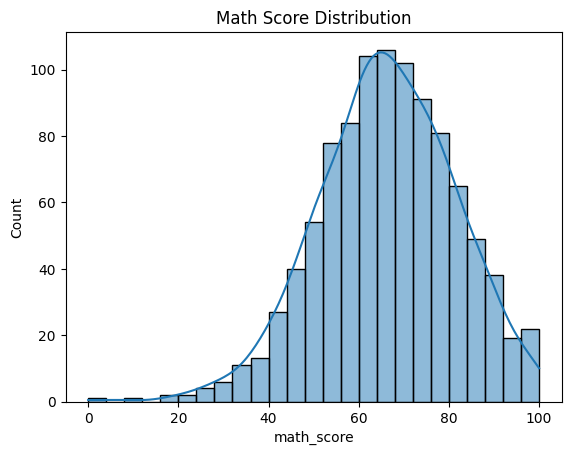

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df["math_score"], kde=True)
plt.title("Math Score Distribution")
plt.show()

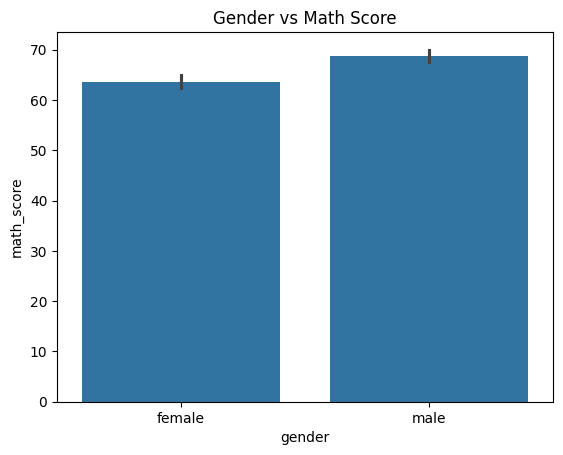

In [12]:
sns.barplot(x="gender", y="math_score", data=df)
plt.title("Gender vs Math Score")
plt.show()

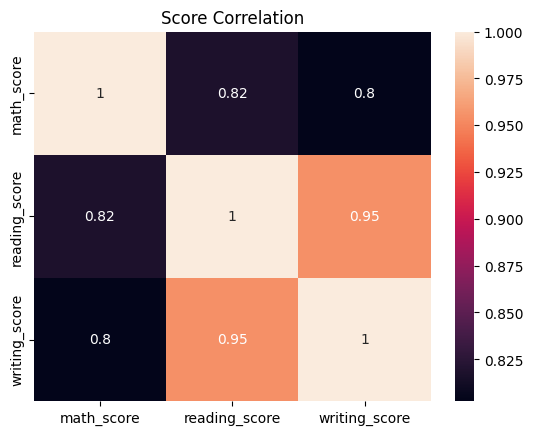

In [13]:
sns.heatmap(df[["math_score","reading_score","writing_score"]].corr(), annot=True)
plt.title("Score Correlation")
plt.show()

In [14]:
print("""
INSIGHTS:
- Reading and writing scores are highly correlated
- Math has slightly more variation
- Gender differences are small
- Parental education affects performance
""")


INSIGHTS:
- Reading and writing scores are highly correlated
- Math has slightly more variation
- Gender differences are small
- Parental education affects performance



In [15]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = df[["reading_score","writing_score"]]
y = df["math_score"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LinearRegression()
model.fit(X_train, y_train)

print("Model score:", model.score(X_test, y_test))

Model score: 0.6835687125226797


In [16]:
import streamlit as st
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("students-performance-in-exams/StudentsPerformance.csv")

st.title("Student Performance Dashboard")

st.write(df.head())

st.subheader("Math Score Distribution")
fig = plt.figure()
sns.histplot(df["math_score"])
st.pyplot(fig)

st.subheader("Gender Comparison")
fig2 = plt.figure()
sns.barplot(x="gender", y="math_score", data=df)
st.pyplot(fig2)

2026-05-23 04:05:41.502 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-23 04:05:41.998 
  command:

    streamlit run C:\Users\PC\AppData\Local\Programs\Python\Python312\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-05-23 04:05:42.000 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-23 04:05:42.001 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-23 04:05:42.019 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-23 04:05:42.021 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-23 04:05:42.021 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-23 04:05:42.

KeyError: 'math_score'

<Figure size 640x480 with 0 Axes>